# Semantic coding of neurons

We preivoulsy launched another script to compute the similarities between Word2Vec and the neuronal activity

After launching this script you can launch this one to compute Fig. 5f and statistics associated

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Analyses on responsive stimuli only

In [4]:
# Path where the results are stored
path_database = 'C:/Users/dornier/PhD/Article/Concept_Cells_temporal_pole/Figures/Figure3/Correlation_Ordered/'

# Load data for the temporal pole
df_tp = pd.read_csv(path_database+'Correlation_Cosine_word2vec_AllDatabase_v1_Responsive.csv')

# Load data for the hippocampus
df_hipp = pd.read_csv(path_database+'Correlation_Cosine_word2vec_AllDatabase_v1_Responsive_hippocampus.csv')

# Load data for the parahippocampal
df_gph = pd.read_csv(path_database+'Correlation_Cosine_word2vec_AllDatabase_v1_Responsive_GPH.csv')

# Load data for the posterior cingulate cortex
df_pcc = pd.read_csv(path_database+'Correlation_Cosine_word2vec_AllDatabase_v1_Responsive_PCC.csv')

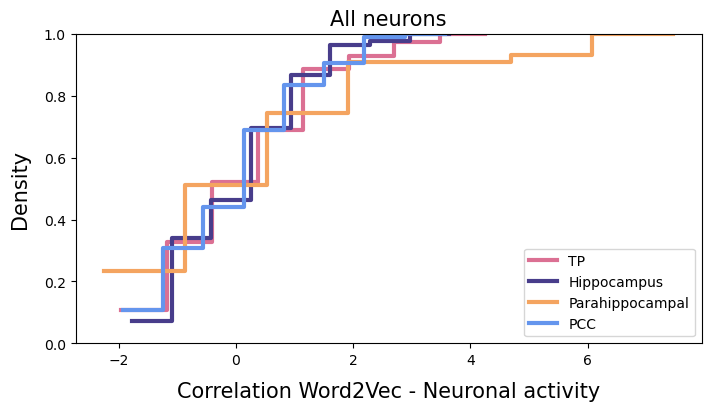

In [38]:
# Test to plot with step plot
import seaborn as sns

fig, ax1 = plt.subplots(1,1,figsize=(7,4),layout='constrained')

sns.histplot(
    data=df_tp, x='Z-score',
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False, ax=ax1,color='palevioletred',linewidth=3
)

sns.histplot(
    data=df_hipp, x='Z-score',
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False, ax=ax1,color='darkslateblue', linewidth=3
)

sns.histplot(
    data=df_gph, x='Z-score',
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False, ax=ax1,color='sandybrown', linewidth=3
)

sns.histplot(
    data=df_pcc, x='Z-score',
    log_scale=False, element="step", fill=False,
    cumulative=True, stat="density", common_norm=False, ax=ax1,color='cornflowerblue',linewidth=3
)

ax1.legend(labels=['TP','Hippocampus','Parahippocampal','PCC'])
ax1.set_xlabel('Correlation Word2Vec - Neuronal activity',fontsize=15,labelpad=10)
ax1.set_ylabel('Density',fontsize=15,labelpad=10)
ax1.set_title('All neurons',fontsize=15)
ax1.set_ylim(0,1)

plt.savefig('C:/Users/dornier/PhD/Article/Concept_Cells_temporal_pole/Figures/Figure5/Correlation_Word2Vec/Cumulative_Plot_Corr_Word2Vec_All_Roi_ResponsiveImages.svg')

In [20]:
# Statistical test

# Transform into an array
cosine_tp = df_tp['Z-score'].values
cosine_hipp = df_hipp['Z-score'].values
cosine_gph = df_gph['Z-score'].values
cosine_pcc = df_pcc['Z-score'].values


# Drop nan values
cosine_tp = cosine_tp[~np.isnan(cosine_tp)]
cosine_hipp = cosine_hipp[~np.isnan(cosine_hipp)]
cosine_gph = cosine_gph[~np.isnan(cosine_gph)]
cosine_pcc = cosine_pcc[~np.isnan(cosine_pcc)]
                      


# First assess if difference between one group with Kruskal-Wallis
res_kruskal = stats.kruskal(cosine_tp, cosine_hipp, cosine_gph, cosine_pcc)

print('Kruskal-wallis: H = '+str(res_kruskal.statistic)+', p = '+str(res_kruskal.pvalue))


import scikit_posthocs as posthoc

# posthoc dunn test, with correction for multiple testing
dunn_df = posthoc.posthoc_dunn(
    [cosine_tp, cosine_hipp, cosine_gph, cosine_pcc], p_adjust='fdr_bh'
)
dunn_df

Kruskal-wallis: H = 1.3851734138023988, p = 0.7090138162684462


,1,2,3,4
1,1.000000,0.911405,0.797884,0.911405
2,0.911405,1.000000,0.797884,0.947632
3,0.797884,0.797884,1.000000,0.797884
4,0.911405,0.947632,0.797884,1.000000
